In [9]:
# ============================================
# SMARTFINANCE - PERSONAL FINANCE ANALYZER
# ============================================

print("Welcome to SmartFinance!")
print("Your Personal Finance Analysis System")


Welcome to SmartFinance!
Your Personal Finance Analysis System


In [10]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

sns.set_theme(style="whitegrid")

print(" Libraries loaded successfully!")


 Libraries loaded successfully!


In [11]:
#  Sample transaction data

data = {
    "Date": [
        "2026-08-01", "2026-08-02", "2026-08-03",
        "2026-08-05", "2026-08-07", "2026-08-10",
        "2026-08-12", "2026-08-15", "2026-08-18",
        "2026-08-20", "2026-08-23", "2026-08-25"
    ],

    "Description": [
        "Salary",
        "Rent",
        "Groceries",
        "Uber",
        "Electricity Bill",
        "Restaurant",
        "Freelance",
        "Shopping",
        "Internet Bill",
        "Fuel",
        "Movie",
        "Salary"
    ],

    "Category": [
        "Income",
        "Housing",
        "Food",
        "Transport",
        "Bills",
        "Food",
        "Income",
        "Shopping",
        "Bills",
        "Transport",
        "Entertainment",
        "Income"
    ],

    "Type": [
        "Income",
        "Expense",
        "Expense",
        "Expense",
        "Expense",
        "Expense",
        "Income",
        "Expense",
        "Expense",
        "Expense",
        "Expense",
        "Income"
    ],

    "Amount": [
        50000,
        15000,
        3500,
        800,
        2200,
        1200,
        12000,
        4500,
        1000,
        2500,
        600,
        50000
    ]
}

df = pd.DataFrame(data)

df["Date"] = pd.to_datetime(df["Date"])

df


,Date,Description,Category,Type,Amount
0,2026-08-01,Salary,Income,Income,50000
1,2026-08-02,Rent,Housing,Expense,15000
2,2026-08-03,Groceries,Food,Expense,3500
3,2026-08-05,Uber,Transport,Expense,800
4,2026-08-07,Electricity Bill,Bills,Expense,2200
5,2026-08-10,Restaurant,Food,Expense,1200
6,2026-08-12,Freelance,Income,Income,12000
7,2026-08-15,Shopping,Shopping,Expense,4500
8,2026-08-18,Internet Bill,Bills,Expense,1000
9,2026-08-20,Fuel,Transport,Expense,2500


In [12]:
# basic infromation 

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (12, 5)

Columns:
['Date', 'Description', 'Category', 'Type', 'Amount']

Data Types:
Date           datetime64[us]
Description               str
Category                  str
Type                      str
Amount                  int64
dtype: object

Missing Values:
Date           0
Description    0
Category       0
Type           0
Amount         0
dtype: int64


In [13]:
# Total Income & Expenses

total_income = df.loc[df["Type"] == "Income", "Amount"].sum()
total_expense = df.loc[df["Type"] == "Expense", "Amount"].sum()

balance = total_income - total_expense

print(f" Total Income   : ₹{total_income:,.2f}")
print(f" Total Expense  : ₹{total_expense:,.2f}")
print(f" Remaining      : ₹{balance:,.2f}")


 Total Income   : ₹112,000.00
 Total Expense  : ₹31,300.00
 Remaining      : ₹80,700.00


In [14]:
# ============================================
# CATEGORY-WISE EXPENSE ANALYSIS
# ============================================

expense_df = df[df["Type"] == "Expense"]

category_expense = (
    expense_df
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("📊 Category-wise Expenses:\n")
print(category_expense)


📊 Category-wise Expenses:

Category
Housing          15000
Food              4700
Shopping          4500
Transport         3300
Bills             3200
Entertainment      600
Name: Amount, dtype: int64


In [15]:
category_percentage = (
    category_expense / total_expense * 100
).round(2)

category_analysis = pd.DataFrame({
    "Amount": category_expense,
    "Percentage": category_percentage
})

category_analysis


,Amount,Percentage
Category,,
Housing,15000,47.92
Food,4700,15.02
Shopping,4500,14.38
Transport,3300,10.54
Bills,3200,10.22
Entertainment,600,1.92


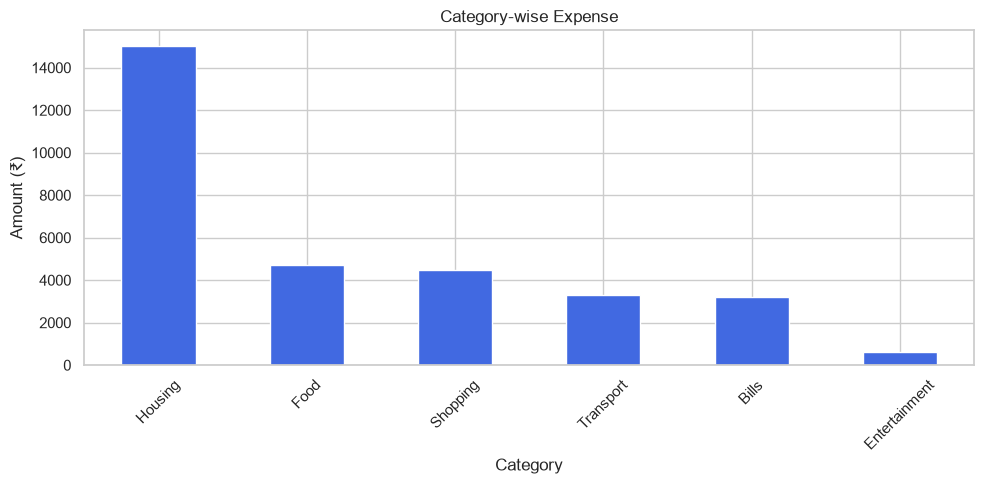

In [16]:
#  Expense Chart

plt.figure(figsize=(10, 5))

category_expense.plot(
    kind="bar",
    color="royalblue"
)

plt.title("Category-wise Expense")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


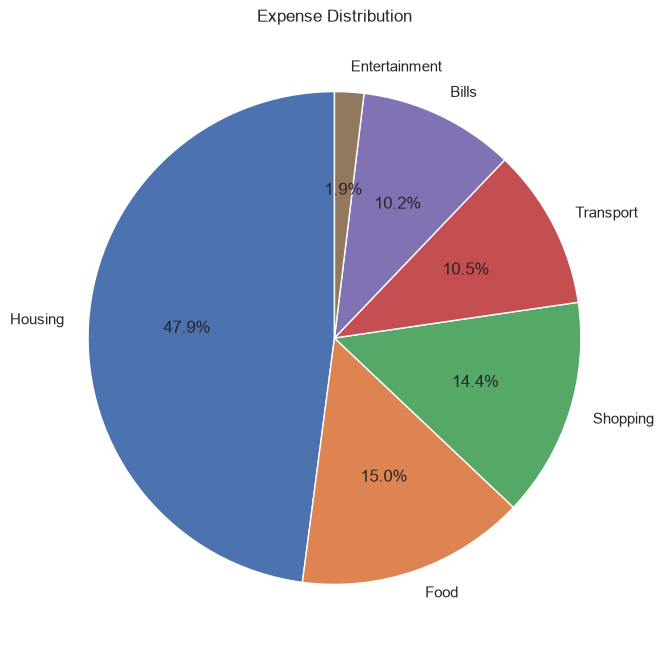

In [19]:
# Expense Distribution

plt.figure(figsize=(8, 8))

plt.pie(
    category_expense,
    labels=category_expense.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Expense Distribution")

plt.show()


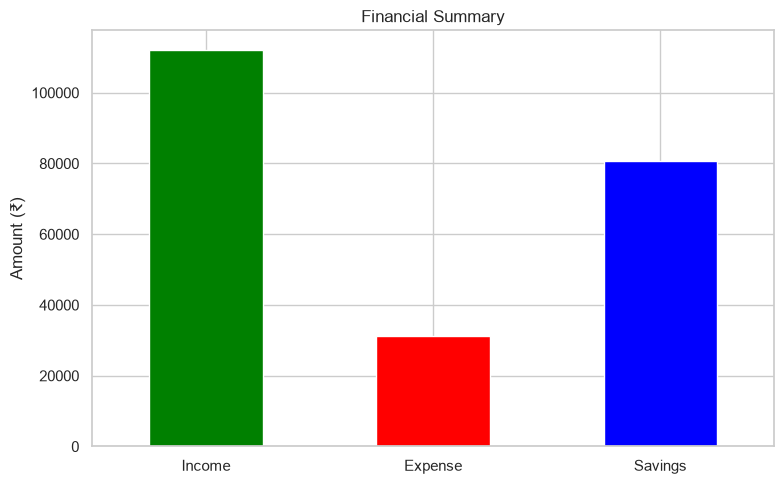

In [20]:
#  Income vs Expense

summary = pd.Series({
    "Income": total_income,
    "Expense": total_expense,
    "Savings": balance
})

plt.figure(figsize=(8, 5))

summary.plot(
    kind="bar",
    color=["green", "red", "blue"]
)

plt.title("Financial Summary")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [21]:
#  Monthly Budget

# ============================================
# BUDGET MANAGEMENT SYSTEM
# ============================================

budget = {
    "Housing": 16000,
    "Food": 5000,
    "Transport": 4000,
    "Bills": 3500,
    "Shopping": 3000,
    "Entertainment": 2000
}

budget_df = pd.DataFrame(
    list(budget.items()),
    columns=["Category", "Budget"]
)

budget_df


,Category,Budget
0,Housing,16000
1,Food,5000
2,Transport,4000
3,Bills,3500
4,Shopping,3000
5,Entertainment,2000


In [22]:
# Actual Spending vs Budget

actual_expense = (
    expense_df
    .groupby("Category")["Amount"]
    .sum()
    .reset_index()
)

budget_analysis = budget_df.merge(
    actual_expense,
    on="Category",
    how="left"
)

budget_analysis["Amount"] = budget_analysis["Amount"].fillna(0)

budget_analysis["Remaining"] = (
    budget_analysis["Budget"] -
    budget_analysis["Amount"]
)

budget_analysis["Used_%"] = (
    budget_analysis["Amount"] /
    budget_analysis["Budget"] * 100
).round(2)

budget_analysis


,Category,Budget,Amount,Remaining,Used_%
0,Housing,16000,15000,1000,93.75
1,Food,5000,4700,300,94.00
2,Transport,4000,3300,700,82.50
3,Bills,3500,3200,300,91.43
4,Shopping,3000,4500,-1500,150.00
5,Entertainment,2000,600,1400,30.00


In [23]:
#  Overspending Detector

def budget_status(row):
    if row["Amount"] > row["Budget"]:
        return "🚨 OVER BUDGET"
    elif row["Used_%"] >= 80:
        return "⚠️ WARNING"
    else:
        return "✅ SAFE"


budget_analysis["Status"] = budget_analysis.apply(
    budget_status,
    axis=1
)

budget_analysis


,Category,Budget,Amount,Remaining,Used_%,Status
0,Housing,16000,15000,1000,93.75,⚠️ WARNING
1,Food,5000,4700,300,94.00,⚠️ WARNING
2,Transport,4000,3300,700,82.50,⚠️ WARNING
3,Bills,3500,3200,300,91.43,⚠️ WARNING
4,Shopping,3000,4500,-1500,150.00,🚨 OVER BUDGET
5,Entertainment,2000,600,1400,30.00,✅ SAFE


In [25]:
# Important Categories find 

over_budget = budget_analysis[
    budget_analysis["Amount"] > budget_analysis["Budget"]
]

warning_categories = budget_analysis[
    (budget_analysis["Used_%"] >= 80) &
    (budget_analysis["Amount"] <= budget_analysis["Budget"])
]

print(" Over Budget:")
print(over_budget[["Category", "Budget", "Amount", "Remaining"]])

print("\n Warning Categories:")
print(warning_categories[["Category", "Budget", "Amount", "Used_%"]])


 Over Budget:
   Category  Budget  Amount  Remaining
4  Shopping    3000    4500      -1500

 Warning Categories:
    Category  Budget  Amount  Used_%
0    Housing   16000   15000   93.75
1       Food    5000    4700   94.00
2  Transport    4000    3300   82.50
3      Bills    3500    3200   91.43


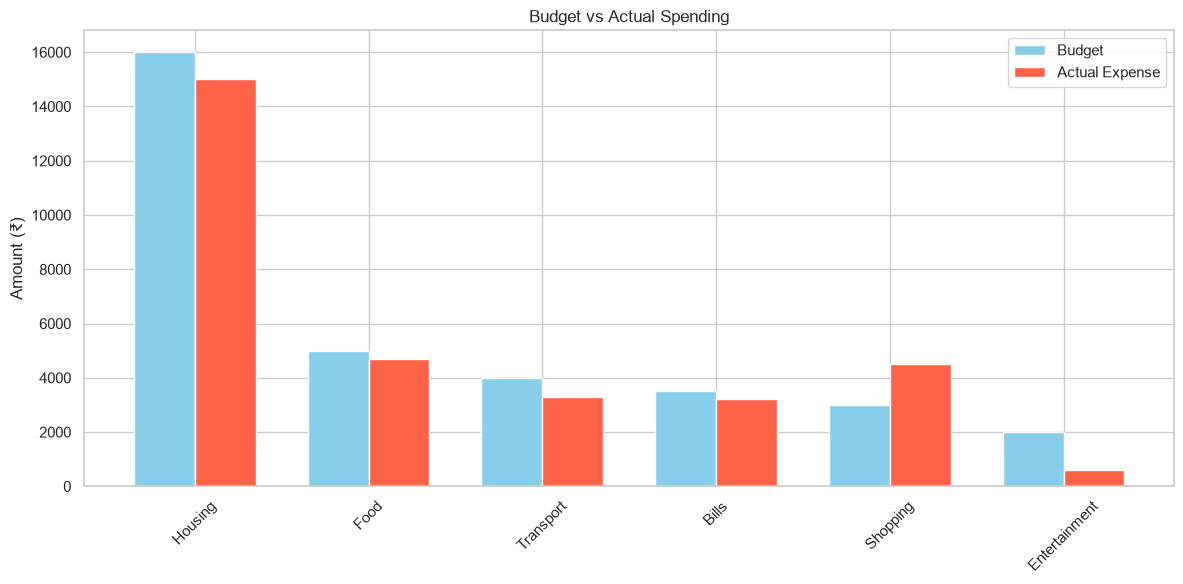

In [26]:
# Budget Visualization

plt.figure(figsize=(12, 6))

x = np.arange(len(budget_analysis))
width = 0.35

plt.bar(
    x - width/2,
    budget_analysis["Budget"],
    width,
    label="Budget",
    color="skyblue"
)

plt.bar(
    x + width/2,
    budget_analysis["Amount"],
    width,
    label="Actual Expense",
    color="tomato"
)

plt.xticks(
    x,
    budget_analysis["Category"],
    rotation=45
)

plt.ylabel("Amount (₹)")
plt.title("Budget vs Actual Spending")
plt.legend()

plt.tight_layout()
plt.show()


In [27]:
# Financial Health Score

# ============================================
# FINANCIAL HEALTH SCORE
# ============================================

savings_ratio = (balance / total_income) * 100

print(f" Savings Ratio: {savings_ratio:.2f}%")


 Savings Ratio: 72.05%


In [29]:
# budget performance

budget_used = (
    budget_analysis["Amount"].sum()
    / budget_analysis["Budget"].sum()
) * 100

budget_score = max(0, 100 - budget_used)

print(f" Budget Used: {budget_used:.2f}%")
print(f" Budget Score: {budget_score:.2f}")


 Budget Used: 93.43%
 Budget Score: 6.57


In [30]:
# Health Score Function

def calculate_health_score(
    savings_ratio,
    budget_score
):
    score = 0

    # Savings component: maximum 50 points
    savings_score = min(savings_ratio * 2, 50)

    # Budget component: maximum 50 points
    budget_component = budget_score * 0.5

    score = savings_score + budget_component

    return round(min(score, 100), 2)


health_score = calculate_health_score(
    savings_ratio,
    budget_score
)

print(f" Financial Health Score: {health_score}/100")


 Financial Health Score: 53.28/100


In [31]:
# Score Category

def score_category(score):
    if score >= 80:
        return " Excellent"
    elif score >= 60:
        return " Good"
    elif score >= 40:
        return " Average"
    elif score >= 20:
        return " Needs Improvement"
    else:
        return " Critical"


health_status = score_category(health_score)

print("Financial Status:", health_status)


Financial Status:  Average


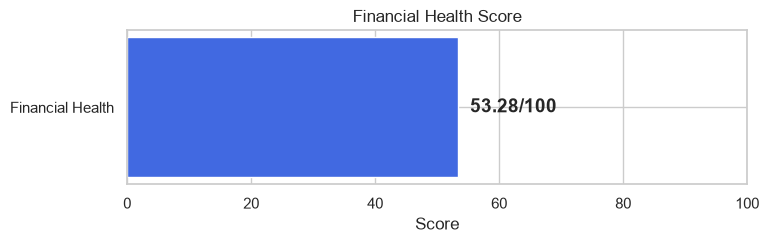

In [32]:
# Visualize Score

plt.figure(figsize=(8, 2))

plt.barh(
    ["Financial Health"],
    [health_score],
    color="royalblue"
)

plt.xlim(0, 100)
plt.xlabel("Score")
plt.title("Financial Health Score")

plt.text(
    health_score + 2,
    0,
    f"{health_score}/100",
    va="center",
    fontsize=14,
    fontweight="bold"
)

plt.show()


In [33]:
# Automatic Financial Advice 
recommendations = []

if savings_ratio < 20:
    recommendations.append(
        " Try to increase your savings to at least 20% of your income."
    )

if budget_used > 80:
    recommendations.append(
        " You are using more than 80% of your total budget."
    )

if len(over_budget) > 0:
    for category in over_budget["Category"]:
        recommendations.append(
            f" Reduce spending in {category}."
        )

if savings_ratio >= 30:
    recommendations.append(
        " Excellent savings discipline! Keep it up."
    )

if not recommendations:
    recommendations.append(
        " Your financial habits look healthy."
    )

print("===== PERSONALIZED FINANCIAL ADVICE =====\n")

for recommendation in recommendations:
    print(recommendation)


===== PERSONALIZED FINANCIAL ADVICE =====

 You are using more than 80% of your total budget.
 Reduce spending in Shopping.
 Excellent savings discipline! Keep it up.


In [34]:
#  Dashboard Data Prepare 

# ============================================
# SMARTFINANCE DASHBOARD
# ============================================

top_category = category_expense.idxmax()
top_category_amount = category_expense.max()

expense_count = len(expense_df)

dashboard_data = {
    "Total Income": total_income,
    "Total Expense": total_expense,
    "Savings": balance,
    "Savings Ratio": savings_ratio,
    "Health Score": health_score,
    "Transactions": expense_count,
    "Top Expense Category": top_category
}

dashboard_data


{'Total Income': np.int64(112000),
 'Total Expense': np.int64(31300),
 'Savings': np.int64(80700),
 'Savings Ratio': np.float64(72.05357142857143),
 'Health Score': np.float64(53.28),
 'Transactions': 9,
 'Top Expense Category': 'Housing'}

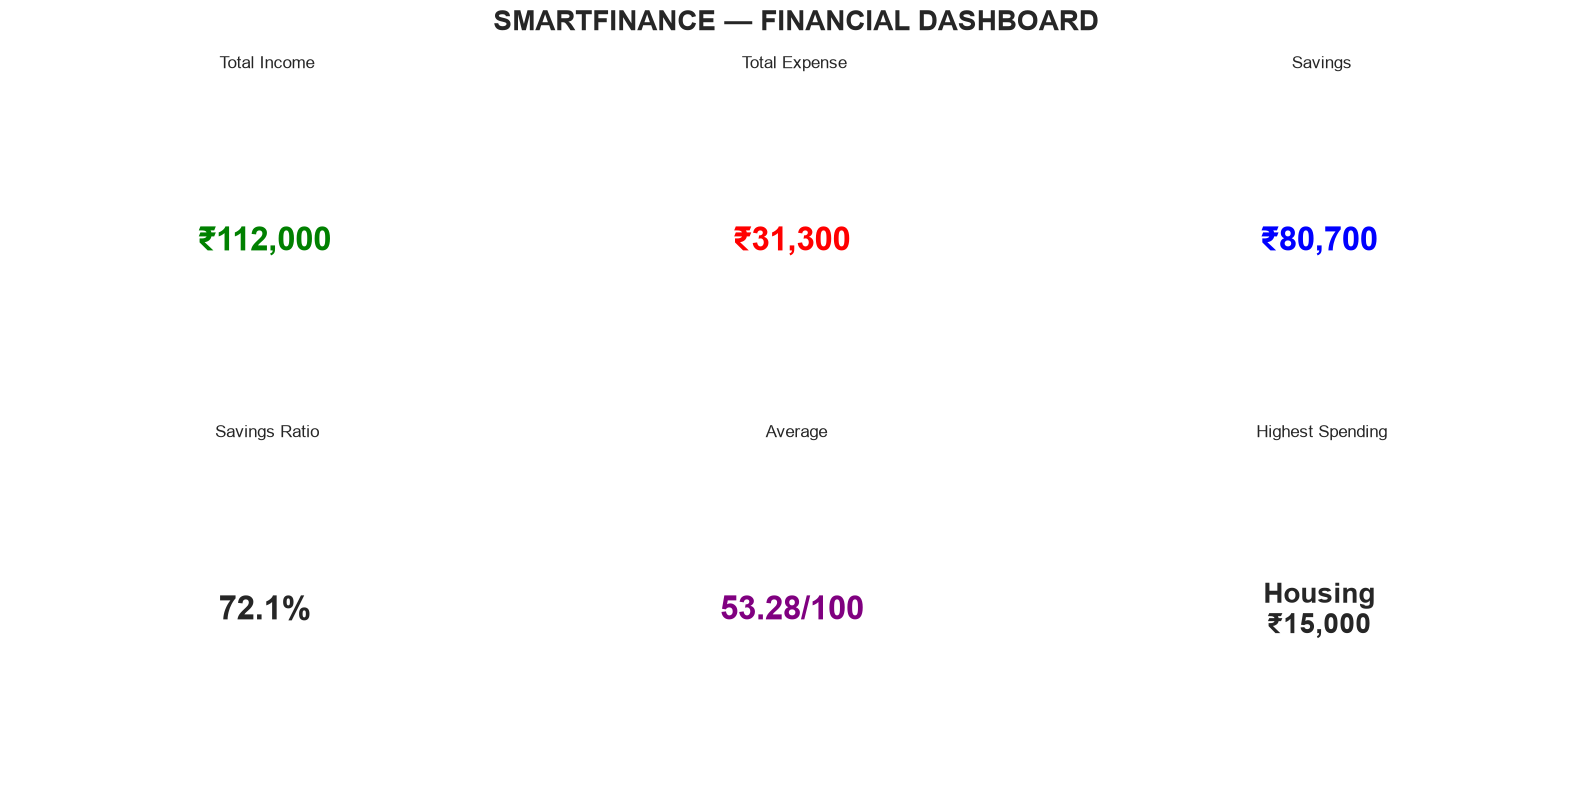

In [35]:
# KPI Dashboard

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

fig.suptitle(
    " SMARTFINANCE — FINANCIAL DASHBOARD",
    fontsize=20,
    fontweight="bold"
)

# 1. Income
axes[0, 0].text(
    0.5, 0.5,
    f"₹{total_income:,.0f}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="green"
)
axes[0, 0].set_title(" Total Income")
axes[0, 0].axis("off")

# 2. Expense
axes[0, 1].text(
    0.5, 0.5,
    f"₹{total_expense:,.0f}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="red"
)
axes[0, 1].set_title(" Total Expense")
axes[0, 1].axis("off")

# 3. Savings
axes[0, 2].text(
    0.5, 0.5,
    f"₹{balance:,.0f}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="blue"
)
axes[0, 2].set_title(" Savings")
axes[0, 2].axis("off")

# 4. Savings Ratio
axes[1, 0].text(
    0.5, 0.5,
    f"{savings_ratio:.1f}%",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)
axes[1, 0].set_title(" Savings Ratio")
axes[1, 0].axis("off")

# 5. Health Score
axes[1, 1].text(
    0.5, 0.5,
    f"{health_score}/100",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="purple"
)
axes[1, 1].set_title(f" {health_status}")
axes[1, 1].axis("off")

# 6. Top Category
axes[1, 2].text(
    0.5, 0.5,
    f"{top_category}\n₹{top_category_amount:,.0f}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)
axes[1, 2].set_title(" Highest Spending")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


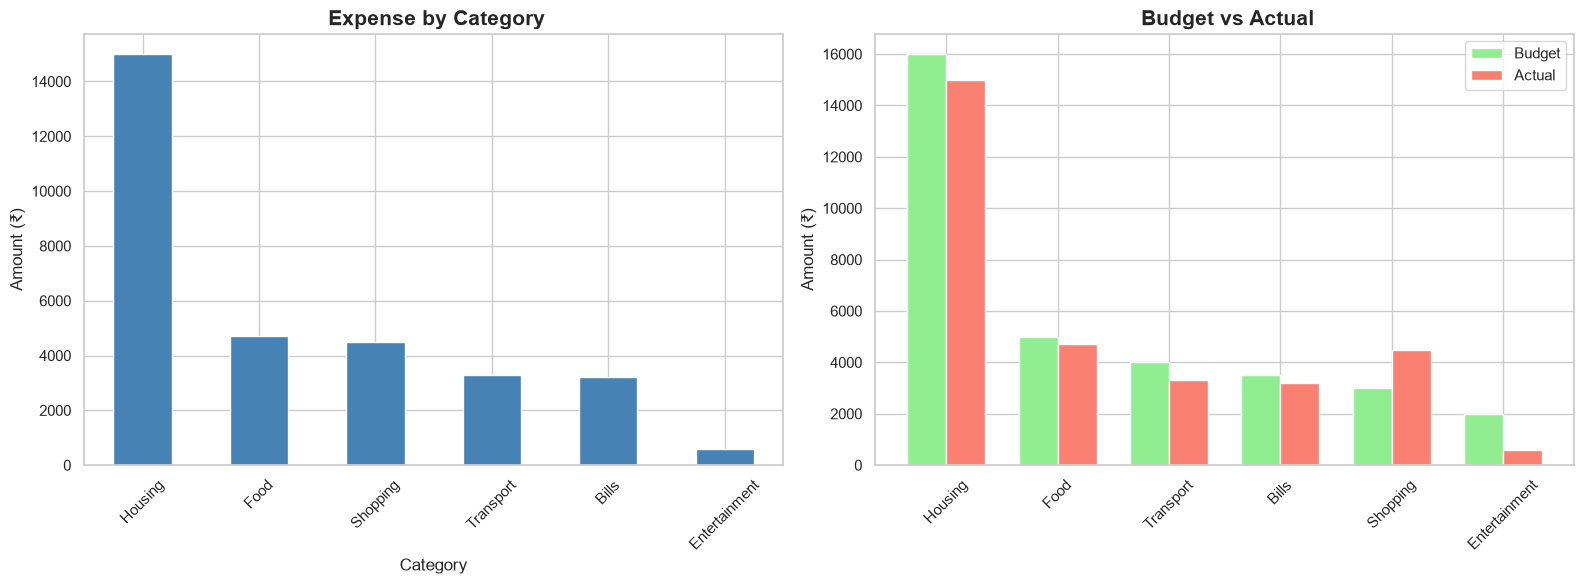

In [36]:
# Dashboard Charts 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Expense by Category
category_expense.plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title(
    " Expense by Category",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Category")
axes[0].set_ylabel("Amount (₹)")
axes[0].tick_params(axis="x", rotation=45)

# Budget comparison
x = np.arange(len(budget_analysis))
width = 0.35

axes[1].bar(
    x - width/2,
    budget_analysis["Budget"],
    width,
    label="Budget",
    color="lightgreen"
)

axes[1].bar(
    x + width/2,
    budget_analysis["Amount"],
    width,
    label="Actual",
    color="salmon"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    budget_analysis["Category"],
    rotation=45
)

axes[1].set_title(
    " Budget vs Actual",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel("Amount (₹)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [37]:
# Final Financial Report

print("=" * 55)
print("           SMARTFINANCE FINANCIAL REPORT")
print("=" * 55)

print(f"\n Total Income       : ₹{total_income:,.2f}")
print(f" Total Expenses     : ₹{total_expense:,.2f}")
print(f" Total Savings      : ₹{balance:,.2f}")
print(f" Savings Ratio      : {savings_ratio:.2f}%")
print(f" Health Score       : {health_score}/100")
print(f" Financial Status   : {health_status}")
print(f" Top Expense        : {top_category}")
print(f" Top Expense Amount : ₹{top_category_amount:,.2f}")

print("\n" + "-" * 55)
print("               RECOMMENDATIONS")
print("-" * 55)

for recommendation in recommendations:
    print(f"\n{recommendation}")

print("\n" + "=" * 55)


           SMARTFINANCE FINANCIAL REPORT

 Total Income       : ₹112,000.00
 Total Expenses     : ₹31,300.00
 Total Savings      : ₹80,700.00
 Savings Ratio      : 72.05%
 Health Score       : 53.28/100
 Financial Status   :  Average
 Top Expense        : Housing
 Top Expense Amount : ₹15,000.00

-------------------------------------------------------
               RECOMMENDATIONS
-------------------------------------------------------

 You are using more than 80% of your total budget.

 Reduce spending in Shopping.

 Excellent savings discipline! Keep it up.



In [51]:
# ============================================
# CSV FILE UPLOAD
# ============================================

import os
import pandas as pd
from IPython.display import display

file_path = input("Enter your CSV file path: ")

if os.path.exists(file_path):
    user_df = pd.read_csv(file_path)

    print("File loaded successfully!")
    print(f"Rows: {user_df.shape[0]}")
    print(f"Columns: {user_df.shape[1]}")

    display(user_df.head())

else:
    print("File not found. Please check the file path.")

Enter your CSV file path:  student_data_final.csv


File loaded successfully!
Rows: 5
Columns: 4


,Name,Age,Marks,Result
0,Aman,21,85,Pass
1,Riya,22,90,Pass
2,Rahul,20,78,Pass
3,Priya,23,92,Pass
4,Neha,21,88,Pass


In [52]:
# Data Validation & Cleaning

# ============================================
# STEP 1 - DATA VALIDATION
# ============================================

required_columns = [
    "Date",
    "Description",
    "Category",
    "Type",
    "Amount"
]

missing_columns = [
    col for col in required_columns
    if col not in user_df.columns
]

if len(missing_columns) == 0:
    print(" CSV format is valid!")
else:
    print(" Missing columns:")
    print(missing_columns)


 Missing columns:
['Date', 'Description', 'Category', 'Type', 'Amount']


In [53]:
# ============================================
# STEP 2 - MISSING VALUES CHECK
# ============================================

print("Missing values in each column:")
print(user_df.isnull().sum())

Missing values in each column:
Name      0
Age       0
Marks     0
Result    0
dtype: int64


In [54]:
# ============================================
# STEP 3 - DUPLICATE RECORDS CHECK
# ============================================

duplicate_count = user_df.duplicated().sum()

print("Duplicate records:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found!")
else:
    print("Duplicate records found.")

Duplicate records: 0
No duplicate records found!


In [55]:
# ============================================
# STEP 4 - DATA TYPES CHECK
# ============================================

print("Data types of each column:")
print(user_df.dtypes)

Data types of each column:
Name        str
Age       int64
Marks     int64
Result      str
dtype: object


In [60]:
# ============================================
# STEP 5 - STUDENT DATA VALIDATION
# ============================================

required_columns = [
    "Name",
    "Age",
    "Marks",
    "Result"
]

missing_columns = [
    col for col in required_columns
    if col not in user_df.columns
]

if len(missing_columns) == 0:
    print("Student CSV format is valid!")
else:
    print("Missing columns:")
    print(missing_columns)

Student CSV format is valid!


In [61]:
# ============================================
# STEP 6 - NUMERIC DATA CLEANING
# ============================================

user_df["Age"] = pd.to_numeric(user_df["Age"], errors="coerce")
user_df["Marks"] = pd.to_numeric(user_df["Marks"], errors="coerce")

print("Age and Marks cleaned successfully!")
print(user_df[["Age", "Marks"]].head())

Age and Marks cleaned successfully!
   Age  Marks
0   21     85
1   22     90
2   20     78
3   23     92
4   21     88


In [62]:
# ============================================
# STEP 7 - MISSING VALUES CHECK
# ============================================

print("Missing values in each column:")
print(user_df.isnull().sum())

Missing values in each column:
Name      0
Age       0
Marks     0
Result    0
dtype: int64


In [63]:
# ============================================
# STEP 8 - DUPLICATE RECORDS CHECK
# ============================================

duplicate_count = user_df.duplicated().sum()

print("Duplicate records:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found!")
else:
    print("Duplicate records found.")

Duplicate records: 0
No duplicate records found!


In [64]:
# ============================================
# STEP 9 - REMOVE MISSING VALUES
# ============================================

user_df = user_df.dropna()

print("Missing rows removed successfully!")
print(f"Rows after cleaning: {user_df.shape[0]}")

Missing rows removed successfully!
Rows after cleaning: 5


In [65]:
# ============================================
# STEP 10 - REMOVE DUPLICATES
# ============================================

user_df = user_df.drop_duplicates()

print("Duplicate records removed successfully!")
print(f"Rows after removing duplicates: {user_df.shape[0]}")

Duplicate records removed successfully!
Rows after removing duplicates: 5


In [66]:
# ============================================
# STEP 11 - NAME CLEANING
# ============================================

user_df["Name"] = user_df["Name"].astype(str).str.strip()

print("Name column cleaned successfully!")
display(user_df.head())

Name column cleaned successfully!


,Name,Age,Marks,Result
0,Aman,21,85,Pass
1,Riya,22,90,Pass
2,Rahul,20,78,Pass
3,Priya,23,92,Pass
4,Neha,21,88,Pass


In [67]:
# ============================================
# STEP 12 - AGE VALIDATION
# ============================================

print("Age range:")
print("Minimum Age:", user_df["Age"].min())
print("Maximum Age:", user_df["Age"].max())

Age range:
Minimum Age: 20
Maximum Age: 23


In [68]:
# ============================================
# STEP 13 - MARKS VALIDATION
# ============================================

print("Marks range:")
print("Minimum Marks:", user_df["Marks"].min())
print("Maximum Marks:", user_df["Marks"].max())

Marks range:
Minimum Marks: 78
Maximum Marks: 92


In [69]:
# ============================================
# STEP 14 - RESULT CLEANING
# ============================================

user_df["Result"] = user_df["Result"].astype(str).str.strip().str.title()

print("Result column cleaned successfully!")
print(user_df["Result"].unique())

Result column cleaned successfully!
<ArrowStringArray>
['Pass']
Length: 1, dtype: str


In [70]:
# ============================================
# STEP 15 - FINAL DATA CHECK
# ============================================

print("Final dataset information:")
print(user_df.info())

display(user_df.head(10))

Final dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    5 non-null      str  
 1   Age     5 non-null      int64
 2   Marks   5 non-null      int64
 3   Result  5 non-null      str  
dtypes: int64(2), str(2)
memory usage: 336.0 bytes
None


,Name,Age,Marks,Result
0,Aman,21,85,Pass
1,Riya,22,90,Pass
2,Rahul,20,78,Pass
3,Priya,23,92,Pass
4,Neha,21,88,Pass


In [71]:
# ============================================
# STEP 16 - SAVE CLEANED DATA
# ============================================

output_file = "cleaned_student_data.csv"

user_df.to_csv(output_file, index=False)

print("Cleaned student data saved successfully!")
print("File name:", output_file)

Cleaned student data saved successfully!
File name: cleaned_student_data.csv


In [72]:
# ============================================
# STEP 17 - FINAL DATASET
# ============================================

print("Final cleaned dataset:")
display(user_df)

Final cleaned dataset:


,Name,Age,Marks,Result
0,Aman,21,85,Pass
1,Riya,22,90,Pass
2,Rahul,20,78,Pass
3,Priya,23,92,Pass
4,Neha,21,88,Pass


In [73]:
# STEP 18 - STUDENT DATA ANALYSIS

print("===== STUDENT DATA ANALYSIS =====")

print("Total Students:", len(user_df))

print("Average Age:", round(user_df["Age"].mean(), 2))

print("Average Marks:", round(user_df["Marks"].mean(), 2))

print("Highest Marks:", user_df["Marks"].max())

print("Lowest Marks:", user_df["Marks"].min())

print("\nResult Distribution:")
print(user_df["Result"].value_counts())

===== STUDENT DATA ANALYSIS =====
Total Students: 5
Average Age: 21.4
Average Marks: 86.6
Highest Marks: 92
Lowest Marks: 78

Result Distribution:
Result
Pass    5
Name: count, dtype: int64


In [74]:
# STEP 19 - TOP STUDENTS

top_students = user_df.sort_values(
    by="Marks",
    ascending=False
).head(5)

print("===== TOP 5 STUDENTS =====")

display(top_students)

===== TOP 5 STUDENTS =====


,Name,Age,Marks,Result
3,Priya,23,92,Pass
1,Riya,22,90,Pass
4,Neha,21,88,Pass
0,Aman,21,85,Pass
2,Rahul,20,78,Pass


In [75]:
# STEP 20 - PASS/FAIL ANALYSIS

result_count = user_df["Result"].value_counts()

print("===== RESULT ANALYSIS =====")

for result, count in result_count.items():
    percentage = (count / len(user_df)) * 100
    print(f"{result}: {count} students ({percentage:.2f}%)")

===== RESULT ANALYSIS =====
Pass: 5 students (100.00%)


In [76]:
# STEP 21 - MARKS CATEGORY

def marks_category(marks):
    if marks >= 75:
        return "Excellent"
    elif marks >= 60:
        return "Good"
    elif marks >= 40:
        return "Average"
    else:
        return "Poor"

user_df["Marks_Category"] = user_df["Marks"].apply(marks_category)

print("Marks category created successfully!")

display(user_df)

Marks category created successfully!


,Name,Age,Marks,Result,Marks_Category
0,Aman,21,85,Pass,Excellent
1,Riya,22,90,Pass,Excellent
2,Rahul,20,78,Pass,Excellent
3,Priya,23,92,Pass,Excellent
4,Neha,21,88,Pass,Excellent


In [77]:
# STEP 22 - MARKS CATEGORY SUMMARY

category_summary = user_df["Marks_Category"].value_counts()

print("===== MARKS CATEGORY SUMMARY =====")

print(category_summary)

===== MARKS CATEGORY SUMMARY =====
Marks_Category
Excellent    5
Name: count, dtype: int64


In [78]:
# STEP 23 - AVERAGE MARKS BY RESULT

result_analysis = user_df.groupby("Result")["Marks"].agg(
    ["count", "mean", "max", "min"]
).round(2)

print("===== RESULT-WISE ANALYSIS =====")

display(result_analysis)

===== RESULT-WISE ANALYSIS =====


,count,mean,max,min
Result,,,,
Pass,5,86.6,92,78


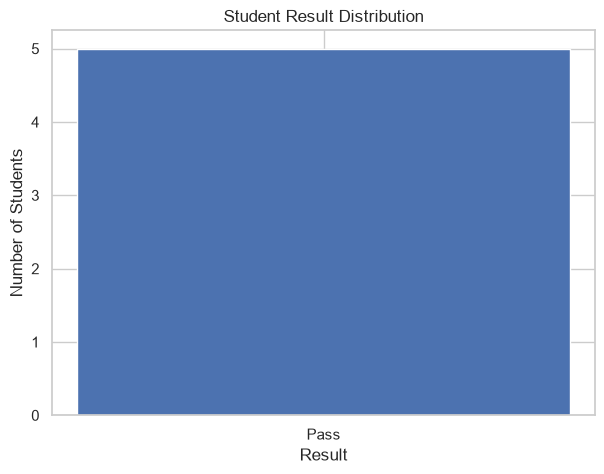

In [79]:
# STEP 24 - RESULT DISTRIBUTION CHART

import matplotlib.pyplot as plt

result_count = user_df["Result"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(result_count.index, result_count.values)

plt.title("Student Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

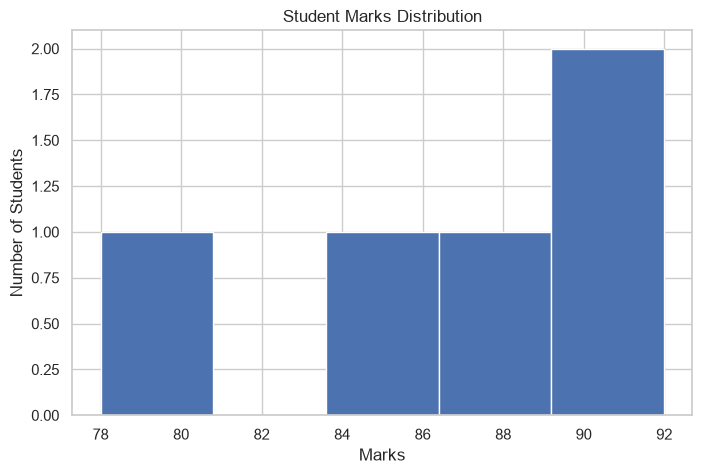

In [80]:
# STEP 25 - MARKS DISTRIBUTION

plt.figure(figsize=(8,5))

plt.hist(user_df["Marks"], bins=5)

plt.title("Student Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Number of Students")

plt.show()

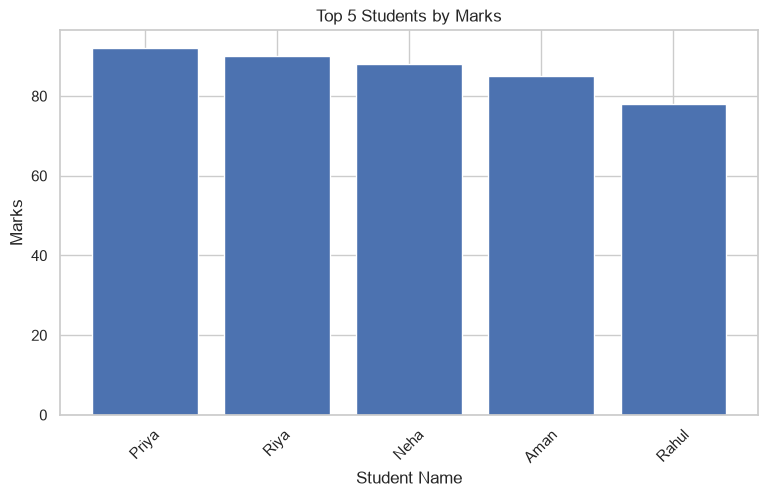

In [81]:
# STEP 26 - TOP 5 STUDENTS CHART

top_students = user_df.sort_values(
    by="Marks",
    ascending=False
).head(5)

plt.figure(figsize=(9,5))

plt.bar(top_students["Name"], top_students["Marks"])

plt.title("Top 5 Students by Marks")
plt.xlabel("Student Name")
plt.ylabel("Marks")

plt.xticks(rotation=45)

plt.show()

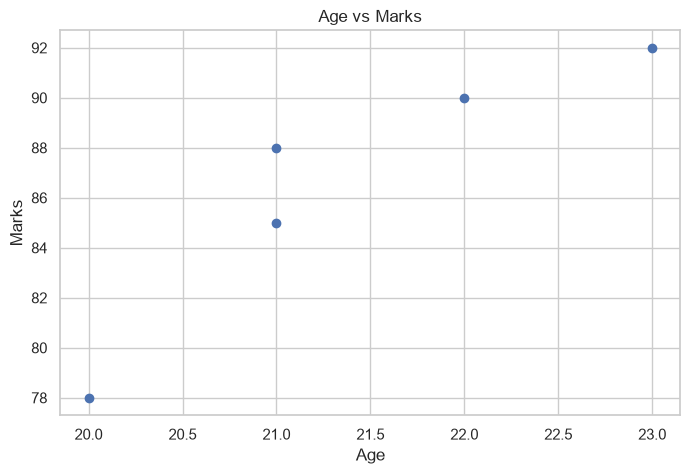

In [82]:
# STEP 27 - AGE VS MARKS

plt.figure(figsize=(8,5))

plt.scatter(user_df["Age"], user_df["Marks"])

plt.title("Age vs Marks")
plt.xlabel("Age")
plt.ylabel("Marks")

plt.show()

In [83]:
# STEP 28 - FINAL PERFORMANCE SUMMARY

total_students = len(user_df)
average_marks = user_df["Marks"].mean()
highest_marks = user_df["Marks"].max()
lowest_marks = user_df["Marks"].min()

pass_count = (user_df["Result"].str.lower() == "pass").sum()
fail_count = (user_df["Result"].str.lower() == "fail").sum()

pass_percentage = (pass_count / total_students) * 100

print("====================================")
print("     STUDENT PERFORMANCE SUMMARY")
print("====================================")

print("Total Students:", total_students)
print("Average Marks:", round(average_marks, 2))
print("Highest Marks:", highest_marks)
print("Lowest Marks:", lowest_marks)
print("Passed Students:", pass_count)
print("Failed Students:", fail_count)
print("Pass Percentage:", round(pass_percentage, 2), "%")

     STUDENT PERFORMANCE SUMMARY
Total Students: 5
Average Marks: 86.6
Highest Marks: 92
Lowest Marks: 78
Passed Students: 5
Failed Students: 0
Pass Percentage: 100.0 %


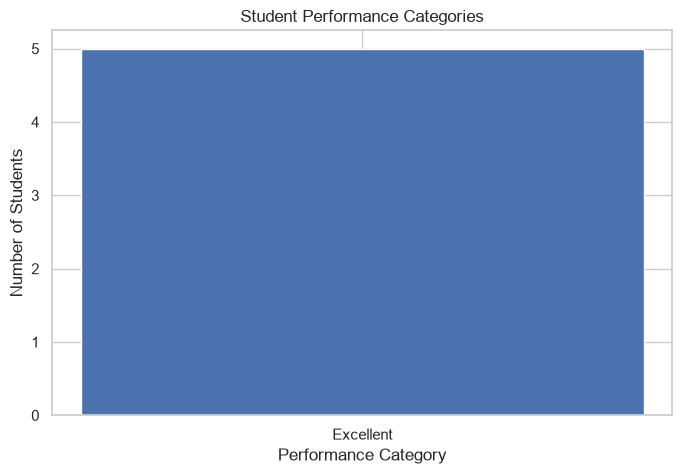

In [84]:
# STEP 29 - PERFORMANCE CATEGORY CHART

category_count = user_df["Marks_Category"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(category_count.index, category_count.values)

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

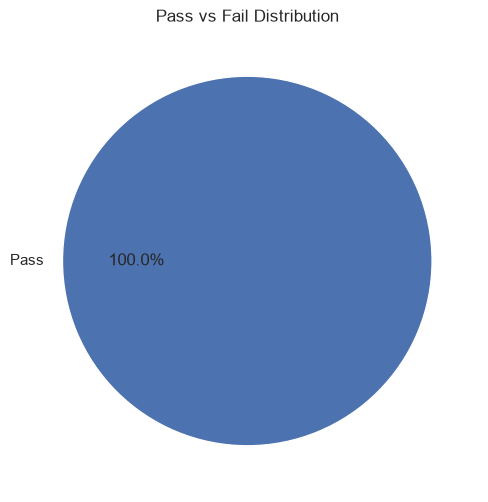

In [85]:
# STEP 30 - RESULT PIE CHART

result_count = user_df["Result"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    result_count.values,
    labels=result_count.index,
    autopct="%1.1f%%"
)

plt.title("Pass vs Fail Distribution")
plt.show()

In [86]:
# STEP 31 - CORRELATION ANALYSIS

correlation = user_df[["Age", "Marks"]].corr()

print("===== CORRELATION BETWEEN AGE AND MARKS =====")
display(correlation)

===== CORRELATION BETWEEN AGE AND MARKS =====


,Age,Marks
Age,1.000000,0.915788
Marks,0.915788,1.000000


In [87]:
# STEP 32 - FINAL ANALYZED DATASET

print("===== FINAL STUDENT DATASET =====")

display(user_df)

===== FINAL STUDENT DATASET =====


,Name,Age,Marks,Result,Marks_Category
0,Aman,21,85,Pass,Excellent
1,Riya,22,90,Pass,Excellent
2,Rahul,20,78,Pass,Excellent
3,Priya,23,92,Pass,Excellent
4,Neha,21,88,Pass,Excellent


In [88]:
# STEP 33 - SAVE FINAL ANALYSIS DATA

final_file = "final_student_analysis.csv"

user_df.to_csv(final_file, index=False)

print("Final student analysis file saved successfully!")
print("File name:", final_file)

Final student analysis file saved successfully!
File name: final_student_analysis.csv


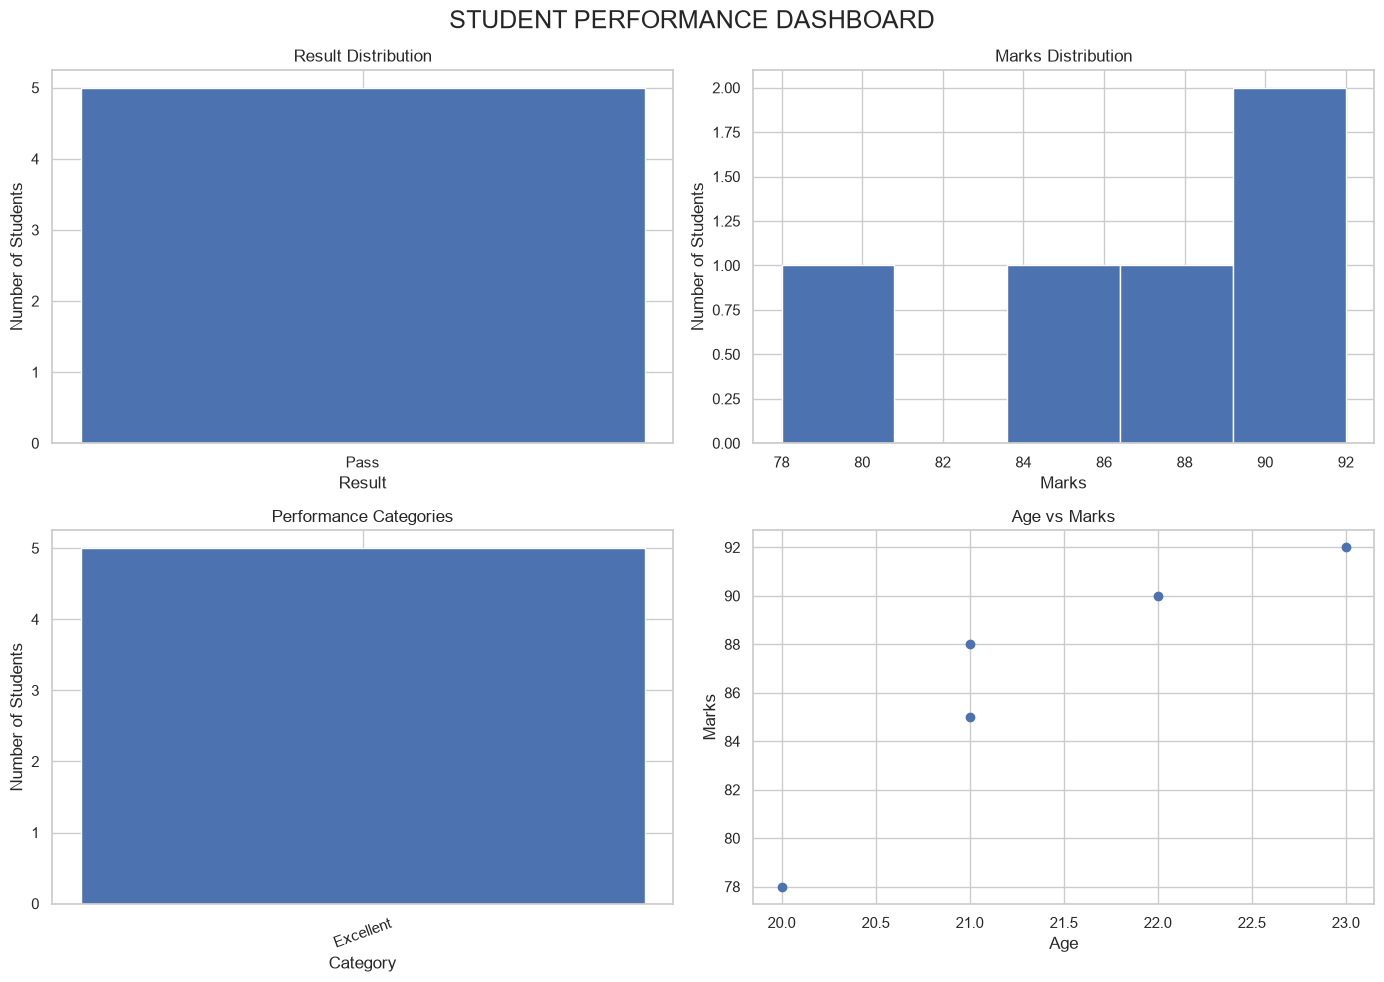

In [89]:
# STEP 34 - FINAL STUDENT PERFORMANCE DASHBOARD

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 10))

# 1. Result Distribution
ax1 = fig.add_subplot(2, 2, 1)
result_count = user_df["Result"].value_counts()
ax1.bar(result_count.index, result_count.values)
ax1.set_title("Result Distribution")
ax1.set_xlabel("Result")
ax1.set_ylabel("Number of Students")

# 2. Marks Distribution
ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(user_df["Marks"], bins=5)
ax2.set_title("Marks Distribution")
ax2.set_xlabel("Marks")
ax2.set_ylabel("Number of Students")

# 3. Performance Categories
ax3 = fig.add_subplot(2, 2, 3)
category_count = user_df["Marks_Category"].value_counts()
ax3.bar(category_count.index, category_count.values)
ax3.set_title("Performance Categories")
ax3.set_xlabel("Category")
ax3.set_ylabel("Number of Students")
ax3.tick_params(axis="x", rotation=20)

# 4. Age vs Marks
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(user_df["Age"], user_df["Marks"])
ax4.set_title("Age vs Marks")
ax4.set_xlabel("Age")
ax4.set_ylabel("Marks")

plt.suptitle("STUDENT PERFORMANCE DASHBOARD", fontsize=18)
plt.tight_layout()
plt.show()

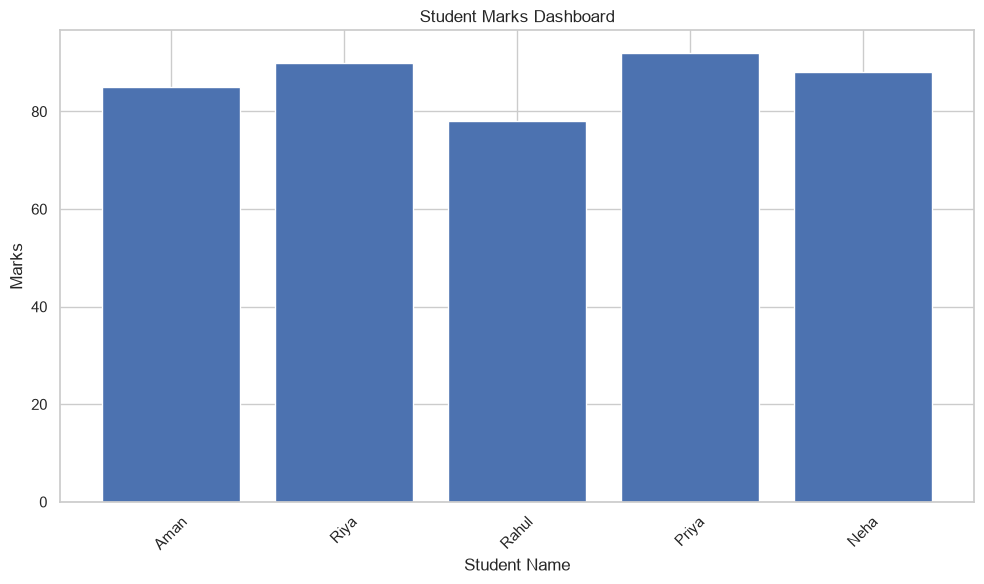

Dashboard saved successfully!
File name: student_performance_dashboard.png


In [90]:
# STEP 35 - SAVE DASHBOARD

plt.figure(figsize=(10, 6))

plt.bar(
    user_df["Name"],
    user_df["Marks"]
)

plt.title("Student Marks Dashboard")
plt.xlabel("Student Name")
plt.ylabel("Marks")
plt.xticks(rotation=45)

plt.tight_layout()

dashboard_file = "student_performance_dashboard.png"
plt.savefig(dashboard_file)

plt.show()

print("Dashboard saved successfully!")
print("File name:", dashboard_file)

In [91]:
# STEP 36 - PROJECT COMPLETION CHECK

print("======================================")
print("       PROJECT COMPLETED")
print("======================================")

print("✓ CSV File Upload")
print("✓ Data Validation")
print("✓ Missing Value Checking")
print("✓ Duplicate Checking")
print("✓ Data Cleaning")
print("✓ Student Data Analysis")
print("✓ Top Students Analysis")
print("✓ Pass/Fail Analysis")
print("✓ Marks Categorization")
print("✓ Data Visualization")
print("✓ Correlation Analysis")
print("✓ Final Dataset Export")
print("✓ Student Performance Dashboard")

print("\nFinal Dataset:")
print("Rows:", user_df.shape[0])
print("Columns:", user_df.shape[1])

print("\nFiles Created:")
print("1. cleaned_student_data.csv")
print("2. final_student_analysis.csv")
print("3. student_performance_dashboard.png")

       PROJECT COMPLETED
✓ CSV File Upload
✓ Data Validation
✓ Missing Value Checking
✓ Duplicate Checking
✓ Data Cleaning
✓ Student Data Analysis
✓ Top Students Analysis
✓ Pass/Fail Analysis
✓ Marks Categorization
✓ Data Visualization
✓ Correlation Analysis
✓ Final Dataset Export
✓ Student Performance Dashboard

Final Dataset:
Rows: 5
Columns: 5

Files Created:
1. cleaned_student_data.csv
2. final_student_analysis.csv
3. student_performance_dashboard.png
